In [1]:
from datetime import datetime
print(f'Run time: {datetime.now().strftime("%D %T")}')

Run time: 04/15/26 23:12:44


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/vjavaly/Baruch-CIS-3920/main/data/liver_cirrhosis_stage_10K.csv", sep = ";")


In [4]:
pd.set_option('display.max_columns', None)

In [5]:
df.shape


(10000, 20)

In [6]:
df.head()

,N_Days,Status,Drug,Age,Gender,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Disease_Stage,Patient_ID
0,2772.0,C,Placebo,16071.0,M,Y,N,Y,N,0.6,217.0,3.62,13.0,414.0,75.95,119.0,292.0,10.2,stage_2,10481
1,1234.0,C,Placebo,21185.0,F,Y,N,Y,N,6.4,373.0,3.46,155.0,1768.0,120.00,151.0,109.0,10.4,stage_3,19109
2,1349.0,C,D-penicillamine,12285.0,F,N,Y,N,N,2.2,572.0,3.77,77.0,2520.0,92.00,114.0,226.0,11.7,stage_3,14801
3,4196.0,C,Placebo,17841.0,F,N,Y,N,N,1.2,258.0,3.57,79.0,2201.0,120.90,76.0,410.0,11.5,stage_3,22491
4,2443.0,C,Placebo,16050.0,F,N,Y,N,N,0.9,308.0,3.69,67.0,696.0,51.15,101.0,278.0,9.9,stage_3,8594


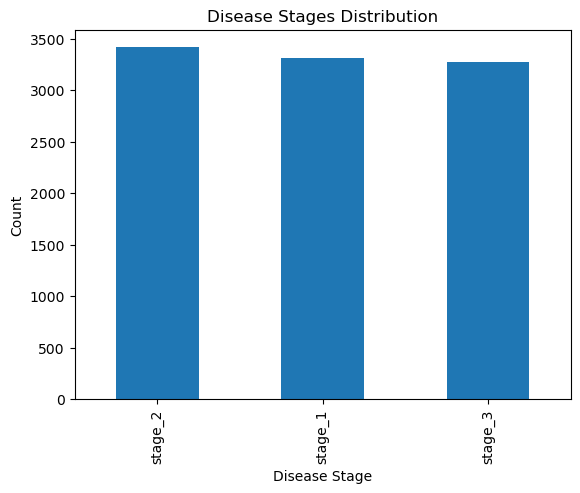

In [7]:
df['Disease_Stage'].value_counts().plot(kind='bar')

plt.title("Disease Stages Distribution")
plt.xlabel("Disease Stage")
plt.ylabel("Count")
plt.show()

In [8]:
df.isnull().sum()

N_Days            18
Status           107
Drug               0
Age               25
Gender            44
Ascites            0
Hepatomegaly       0
Spiders            0
Edema              0
Bilirubin          0
Cholesterol        0
Albumin            0
Copper             0
Alk_Phos           0
SGOT               0
Tryglicerides      0
Platelets          0
Prothrombin        0
Disease_Stage      0
Patient_ID         0
dtype: int64

In [9]:

df[df.select_dtypes(include=['number']).columns] = SimpleImputer(strategy='mean').fit_transform(     #clarified with chatgpt that this was the best and most efficient method for imputing 
    df.select_dtypes(include=['number'])
)
df[df.select_dtypes(include=['object']).columns] = SimpleImputer(strategy='most_frequent').fit_transform(
    df.select_dtypes(include=['object'])
)

In [10]:
df.isnull().sum()

N_Days           0
Status           0
Drug             0
Age              0
Gender           0
Ascites          0
Hepatomegaly     0
Spiders          0
Edema            0
Bilirubin        0
Cholesterol      0
Albumin          0
Copper           0
Alk_Phos         0
SGOT             0
Tryglicerides    0
Platelets        0
Prothrombin      0
Disease_Stage    0
Patient_ID       0
dtype: int64

In [11]:
df = pd.get_dummies(
    df,
    columns=['Status', 'Drug', 'Gender', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema'], #chatgpt helped me identify that "Edema"  was not encoded before KNN causing a ValueError. I used one-hot encoding to fix this.
    drop_first=True
)

In [12]:
df.head()

,N_Days,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Disease_Stage,Patient_ID,Status_CL,Status_D,Drug_Placebo,Gender_M,Ascites_Y,Hepatomegaly_Y,Spiders_Y,Edema_S,Edema_Y
0,2772.0,16071.0,0.6,217.0,3.62,13.0,414.0,75.95,119.0,292.0,10.2,stage_2,10481.0,False,False,True,True,True,False,True,False,False
1,1234.0,21185.0,6.4,373.0,3.46,155.0,1768.0,120.00,151.0,109.0,10.4,stage_3,19109.0,False,False,True,False,True,False,True,False,False
2,1349.0,12285.0,2.2,572.0,3.77,77.0,2520.0,92.00,114.0,226.0,11.7,stage_3,14801.0,False,False,False,False,False,True,False,False,False
3,4196.0,17841.0,1.2,258.0,3.57,79.0,2201.0,120.90,76.0,410.0,11.5,stage_3,22491.0,False,False,True,False,False,True,False,False,False
4,2443.0,16050.0,0.9,308.0,3.69,67.0,696.0,51.15,101.0,278.0,9.9,stage_3,8594.0,False,False,True,False,False,True,False,False,False


In [13]:
le = LabelEncoder()
df['Disease_Stage'] = le.fit_transform(df['Disease_Stage'])

In [14]:
X = df.drop(['Disease_Stage', 'Patient_ID'], axis=1)
y = df['Disease_Stage']

In [15]:
scaler = StandardScaler()

num_cols = X.select_dtypes(include=['float64', 'int64']).columns #Used chatgpt to confirm that scaling was the best method for KNN
X[num_cols] = scaler.fit_transform(X[num_cols])

In [16]:
X.head()

,N_Days,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Status_CL,Status_D,Drug_Placebo,Gender_M,Ascites_Y,Hepatomegaly_Y,Spiders_Y,Edema_S,Edema_Y
0,0.807184,-0.646558,-0.590372,-0.785022,0.354506,-1.190059,-0.883550,-0.999549,-0.071521,0.367795,-0.591817,False,False,True,True,True,False,True,False,False
1,-0.603528,0.721510,0.638170,-0.003023,-0.064328,0.760917,-0.126081,-0.064202,0.548291,-1.485774,-0.370562,False,False,True,False,True,False,True,False,False
2,-0.498046,-1.659368,-0.251463,0.994527,0.747162,-0.310746,0.294611,-0.658747,-0.168366,-0.300705,1.067597,False,False,False,False,False,True,False,False,False
3,2.113330,-0.173058,-0.463281,-0.579497,0.223620,-0.283267,0.116152,-0.045092,-0.904392,1.562993,0.846341,False,False,True,False,False,True,False,False,False
4,0.505412,-0.652176,-0.526826,-0.328856,0.537746,-0.448138,-0.725790,-1.526146,-0.420165,0.225992,-0.923700,False,False,True,False,False,True,False,False,False


In [17]:
y.head()

0    1
1    2
2    2
3    2
4    2
Name: Disease_Stage, dtype: int64

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [20]:
y_pred = knn.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8615


In [21]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.85      0.85       673
           1       0.83      0.85      0.84       686
           2       0.90      0.89      0.89       641

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000



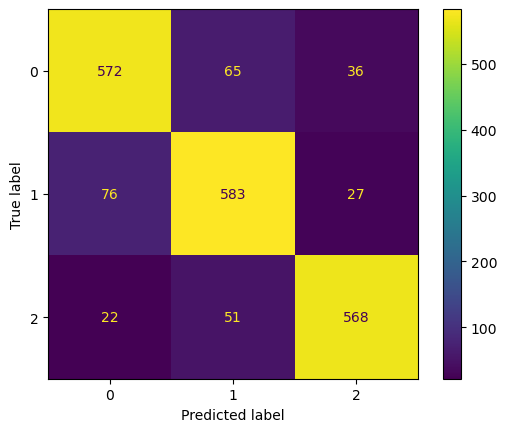

In [22]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

In [23]:
knn_tuned = KNeighborsClassifier( #Ran my parameters through chatgpt to confirm they were the best for tuning KNN
    n_neighbors=5,
    weights='distance',
    metric='manhattan'
)
knn_tuned.fit(X_train, y_train)

KNeighborsClassifier(metric='manhattan', weights='distance')

In [24]:
y_pred_tuned = knn_tuned.predict(X_test)

t_accuracy = accuracy_score(y_test, y_pred_tuned)
print("Accuracy:", t_accuracy)

Accuracy: 0.9215


In [25]:
print(classification_report(y_test, y_pred_tuned))

              precision    recall  f1-score   support

           0       0.92      0.91      0.92       673
           1       0.91      0.92      0.91       686
           2       0.94      0.94      0.94       641

    accuracy                           0.92      2000
   macro avg       0.92      0.92      0.92      2000
weighted avg       0.92      0.92      0.92      2000



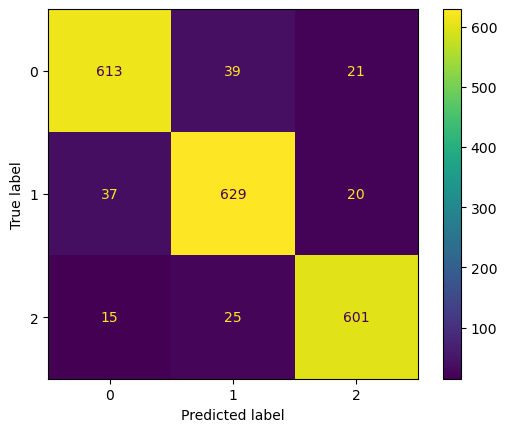

In [26]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tuned)
plt.show()

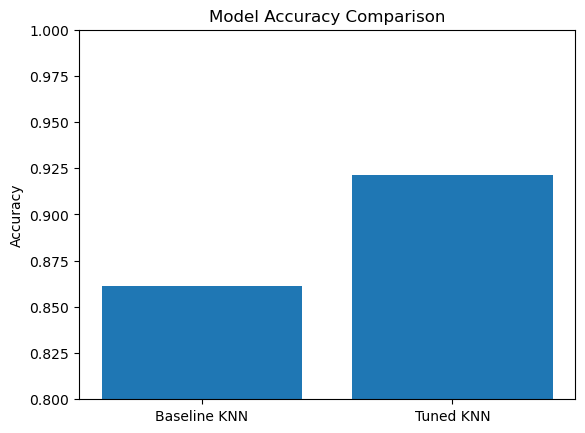

In [27]:
models = ['Baseline KNN', 'Tuned KNN']
accuracies = [accuracy, t_accuracy]

plt.bar(models, accuracies)

plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0.8, 1.0)  

plt.show()